# EDA — Account Intent & Fit Scoring Engine

This notebook explores `data/accounts.csv` before any modeling happens. The goal is to understand the shape of the data, how `fit_score` and `intent_score` behave, and how they relate to `opportunity_created` (our label) — so that later modeling choices are grounded in what the data actually looks like, not assumptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/accounts.csv")
df.shape

(2500, 17)

## 1. Dataset shape & class balance

First question for any classification problem: how many rows/columns do we have, and how imbalanced is the label? A very rare positive class (e.g. 2%) needs different handling than a roughly 1-in-5 split.

Rows: 2500, Columns: 17

Class balance (opportunity_created):
opportunity_created
0    0.802
1    0.198
Name: proportion, dtype: float64


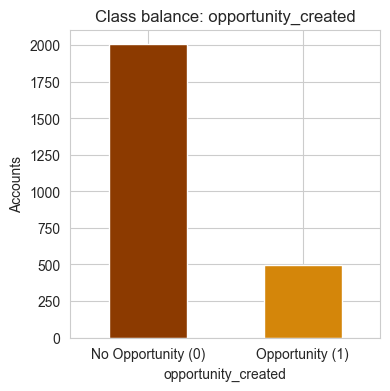

In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()
class_balance = df["opportunity_created"].value_counts(normalize=True).round(3)
print("Class balance (opportunity_created):")
print(class_balance)

fig, ax = plt.subplots(figsize=(4, 4))
df["opportunity_created"].value_counts().sort_index().plot(
    kind="bar", color=["#8C3A00", "#D4860A"], ax=ax
)
ax.set_xticklabels(["No Opportunity (0)", "Opportunity (1)"], rotation=0)
ax.set_title("Class balance: opportunity_created")
ax.set_ylabel("Accounts")
plt.show()

## 2. Distribution of fit_score and intent_score

These are our two engineered composite scores — `fit_score` from firmographics, `intent_score` from behavior. Checking their distributions confirms they're spread out (not clustered at one value) and roughly on the intended 0-100 scale.

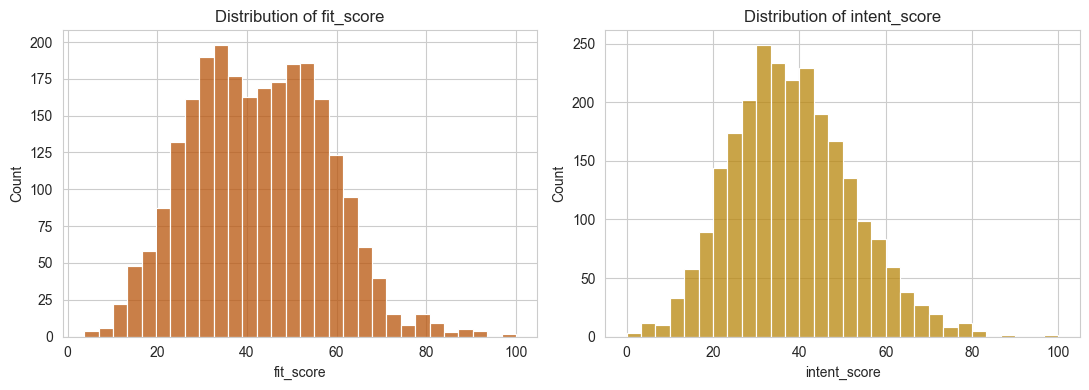

,fit_score,intent_score
count,2500.0,2500.0
mean,42.6,38.2
std,15.0,13.9
min,3.7,0.0
25%,31.2,28.6
50%,42.4,37.5
75%,53.6,47.3
max,100.0,100.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["fit_score"], bins=30, color="#B8540A", ax=axes[0])
axes[0].set_title("Distribution of fit_score")
sns.histplot(df["intent_score"], bins=30, color="#B8860B", ax=axes[1])
axes[1].set_title("Distribution of intent_score")
plt.tight_layout()
plt.show()

df[["fit_score", "intent_score"]].describe().round(1)

## 3. Conversion rate by industry and by account tier

Does the account's industry or size tier affect how likely it is to convert to an opportunity? This is a first look at whether firmographic segments behave differently — useful context for sales/marketing prioritization.

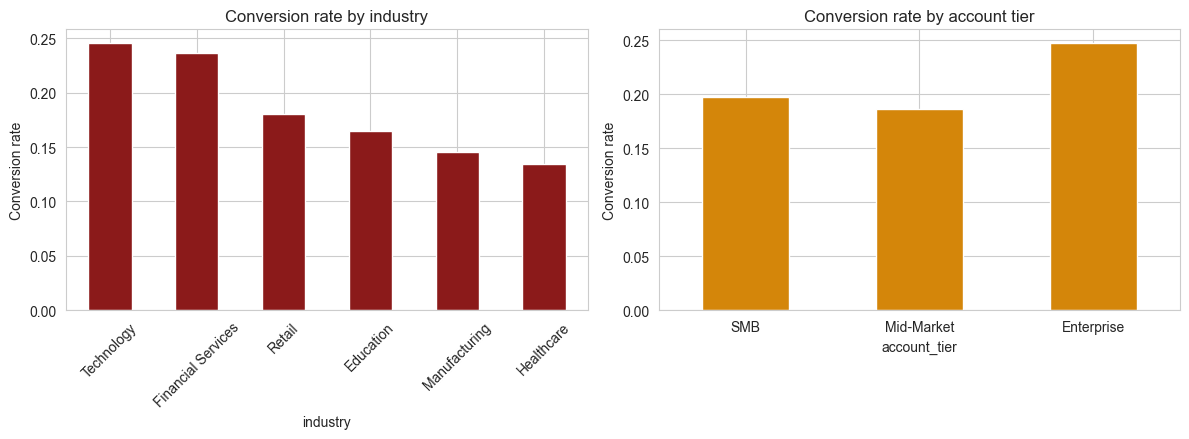

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

conv_by_industry = df.groupby("industry")["opportunity_created"].mean().sort_values(ascending=False)
conv_by_industry.plot(kind="bar", color="#8B1A1A", ax=axes[0])
axes[0].set_title("Conversion rate by industry")
axes[0].set_ylabel("Conversion rate")
axes[0].tick_params(axis="x", rotation=45)

tier_order = ["SMB", "Mid-Market", "Enterprise"]
conv_by_tier = df.groupby("account_tier")["opportunity_created"].mean().reindex(tier_order)
conv_by_tier.plot(kind="bar", color="#D4860A", ax=axes[1])
axes[1].set_title("Conversion rate by account tier")
axes[1].set_ylabel("Conversion rate")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4. Correlation heatmap of numeric features

A quick way to spot redundant features (highly correlated with each other) and to sanity-check that `fit_score`/`intent_score` correlate with the raw signals they were built from.

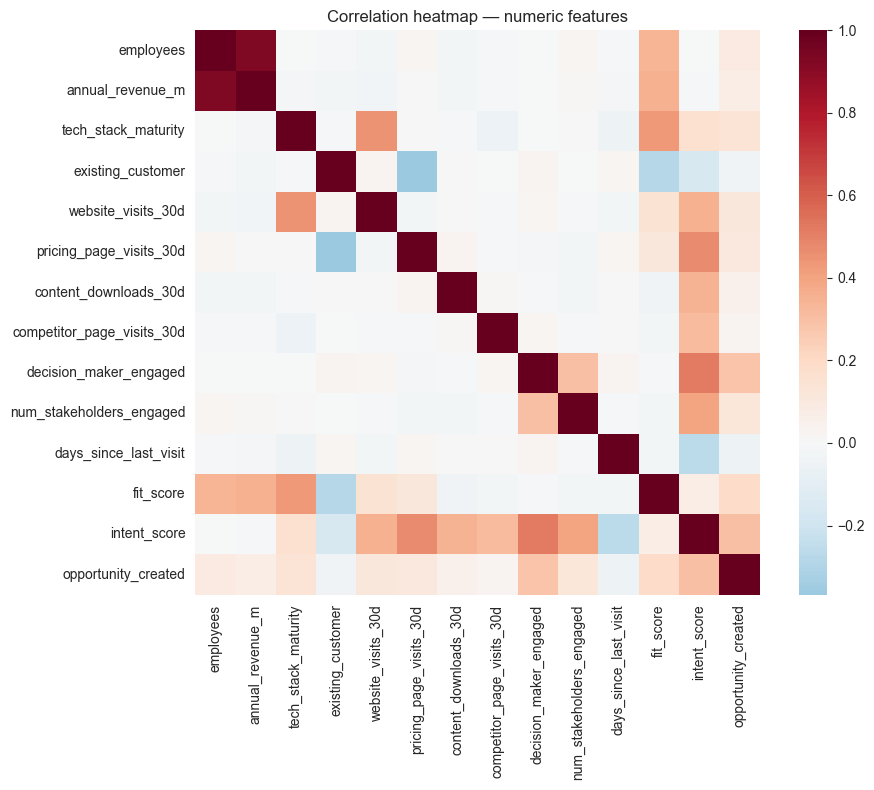

In [5]:
numeric_cols = [
    "employees", "annual_revenue_m", "tech_stack_maturity", "existing_customer",
    "website_visits_30d", "pricing_page_visits_30d", "content_downloads_30d",
    "competitor_page_visits_30d", "decision_maker_engaged", "num_stakeholders_engaged",
    "days_since_last_visit", "fit_score", "intent_score", "opportunity_created",
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, square=True, ax=ax)
ax.set_title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()

## 5. fit_score vs intent_score, colored by opportunity_created

This is the scatter plot that becomes the Account Heatmap in the dashboard. Here we check: do converted accounts (orange) actually cluster toward high-fit/high-intent, or is the signal too noisy to see visually?

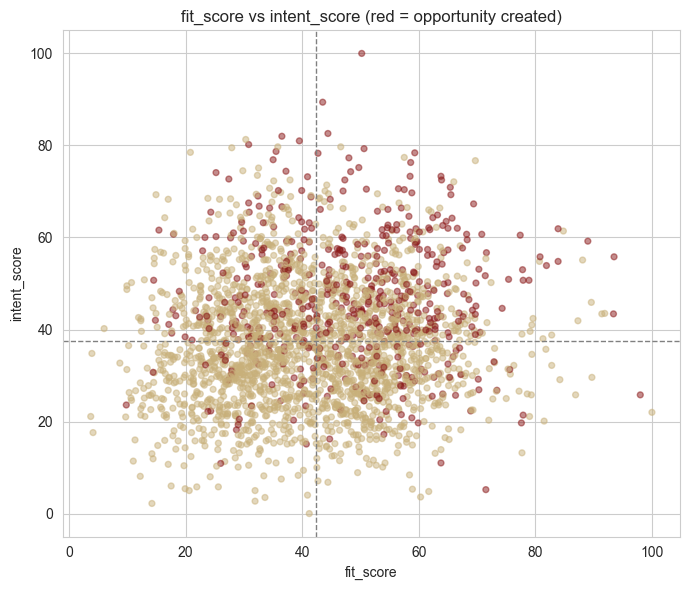

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = df["opportunity_created"].map({0: "#C8B07A", 1: "#8B1A1A"})
ax.scatter(df["fit_score"], df["intent_score"], c=colors, alpha=0.5, s=18)
ax.axvline(df["fit_score"].median(), color="gray", linestyle="--", linewidth=1)
ax.axhline(df["intent_score"].median(), color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("fit_score")
ax.set_ylabel("intent_score")
ax.set_title("fit_score vs intent_score (red = opportunity created)")
plt.tight_layout()
plt.show()

## Key takeaways

1. **The label is realistically imbalanced (~20% positive)**, not 50/50 — mirrors real B2B pipelines where most accounts never convert, and rules out a model that's trivially accurate by always predicting "no."
2. **fit_score and intent_score are roughly bell-shaped and span the full 0-100 range**, confirming the composite scoring logic in `generate_data.py` produces usable spread rather than a degenerate distribution.
3. **Technology and Financial Services convert at a higher rate**, consistent with how `fit_score` was designed to weight those industries — a sanity check that the simulation behaves as intended.
4. **The fit vs. intent scatter shows a visible but noisy skew** toward the top-right (high fit + high intent) for converted accounts — exactly the "learnable but not perfect" signal we want, since real buying behavior is never fully deterministic from firmographics + engagement alone.